# Homework 2: Supervised Learning 
Joshua Ng

## 1. Classification

In [115]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/homeworks/hw2/data/properties.csv", index_col=0)
compositions = pd.read_csv("https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/homeworks/hw2/data/compositions.csv", index_col=0)
X = compositions.values # inputs for ML models
y = df["beta"] # output property

df.head()

,id,eid,formula,R1,R2,R3,F1,F2,F3,P0,...,HV_err,moe,moe_class,ph1,ph2,ph3,condition,comments,composition,beta
0,1,Ti-23Nb-10Zr-2.0Fe,Ti0.7791Fe0.0234Zr0.0617Nb0.1358,1,10.1007/s10853-021-06002-0,salvador2021,1,0,0,1860.0,...,8.0,12.88,meta,Ti-beta,NaN,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.7791 Fe0.0234 Zr0.0617 Nb0.1358,1
1,2,Ti-27Nb-10Zr-1.5Fe,Ti0.7575Fe0.0156Zr0.0637Nb0.1632,1,10.1007/s10853-021-06002-0,salvador2021,1,1,0,1400.0,...,2.0,11.65,meta,Ti-beta,NaN,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.7575 Fe0.0156 Zr0.0637 Nb0.1632,1
2,3,Ti-31Nb-10Zr-1.0Fe,Ti0.7298Fe0.0138Zr0.0664Nb0.1899,1,10.1007/s10853-021-06002-0,salvador2021,1,0,0,1310.0,...,5.0,12.08,meta,Ti-beta,NaN,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.7298 Fe0.0138 Zr0.0664 Nb0.1899,1
3,4,Ti-11Nb-7Zr-3.5Fe,Ti0.8622Fe0.0349Zr0.041Nb0.0618,2,10.1016/j.matdes.2018.10.040,dalbo2018,1,1,0,1640.0,...,3.0,13.78,meta,Ti-beta,Ti-omega,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.8622 Fe0.0349 Zr0.041 Nb0.0618,1
4,5,Ti-19Nb-6Sn-2.5Fe,Ti0.8376Fe0.0256Nb0.11Sn0.0268,2,10.1016/j.matdes.2018.10.040,dalbo2018,1,1,0,1280.0,...,9.0,12.76,meta,Ti-beta,Ti-omega,NaN,ST-WQ,Young modulus obtained via tensile tests (Tabl...,Ti0.8376 Fe0.0256 Nb0.11 Sn0.0268,1


### 1.1 Training and Evaluating Classifiers

In [116]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state= 68)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)
print(x_train.shape)
print(x_test.shape)


(226, 17)
(57, 17)


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [118]:
models = {
    "logistic": LogisticRegression(),
    "SVC": SVC(probability=True),
    "tree": DecisionTreeClassifier(),
    "rf": RandomForestClassifier(),
    "knns": KNeighborsClassifier(),
    "xgboost": XGBClassifier()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Evaluate metrics
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

    # Conditionally format roc_auc based on its type
    roc_auc_str = f"{roc_auc:.4f}" if isinstance(roc_auc, float) else str(roc_auc)
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC AUC: {roc_auc_str}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)


Training logistic...
logistic - Accuracy: 0.8772, Precision: 0.8654, Recall: 1.0000, F1-score: 0.9278, ROC AUC: 0.8741

Training SVC...
SVC - Accuracy: 0.8947, Precision: 0.8824, Recall: 1.0000, F1-score: 0.9375, ROC AUC: 0.8593

Training tree...
tree - Accuracy: 0.8947, Precision: 0.9333, Recall: 0.9333, F1-score: 0.9333, ROC AUC: 0.8389

Training rf...
rf - Accuracy: 0.9123, Precision: 0.9167, Recall: 0.9778, F1-score: 0.9462, ROC AUC: 0.8759

Training knns...
knns - Accuracy: 0.8772, Precision: 0.9130, Recall: 0.9333, F1-score: 0.9231, ROC AUC: 0.8759

Training xgboost...
xgboost - Accuracy: 0.8947, Precision: 0.9149, Recall: 0.9556, F1-score: 0.9348, ROC AUC: 0.9278


,accuracy,precision,recall,f1_score,roc_auc
logistic,0.877193,0.865385,1.000000,0.927835,0.874074
SVC,0.894737,0.882353,1.000000,0.937500,0.859259
tree,0.894737,0.933333,0.933333,0.933333,0.838889
rf,0.912281,0.916667,0.977778,0.946237,0.875926
knns,0.877193,0.913043,0.933333,0.923077,0.875926
xgboost,0.894737,0.914894,0.955556,0.934783,0.927778


The dataset is quite small, so the models in general behaved quite similarly. Rf is the best models here by all metrics of accuracy, precision, recall, and f1_score. 

### 1.2 Interpreting the Classifiers

In [119]:
cols = ['Ti', 'Fe', 'Zr', 'Nb', 'Sn', 'Ta', 'Mo', 'Al', 'V', 'Cr', 'Cu', 'Hf', 'Mn', 'W', 'Ni', 'Sc', 'Si']
col_to_idx = {name: i for i, name in enumerate(cols)}
percentages = np.arange(0.1, 51, 0.1)
num_rows = len(percentages)
num_cols = len(cols)

synthetic_dict = {}

for element in cols:
    if element == 'Ti':
        continue
    element_array = np.zeros((num_rows, num_cols))
    target_idx = col_to_idx[element]
    element_array[:, target_idx] = percentages
    element_array[:, 0] = 100 - percentages
    synthetic_dict[element] = element_array

# --- Verification ---
print(f"Keys available: {list(synthetic_dict.keys())}")
print(f"Shape of 'Fe' array: {synthetic_dict['Fe'].shape}")
print("\nFirst 3 rows of Fe series:")
print(synthetic_dict['Fe'][:3])

Keys available: ['Fe', 'Zr', 'Nb', 'Sn', 'Ta', 'Mo', 'Al', 'V', 'Cr', 'Cu', 'Hf', 'Mn', 'W', 'Ni', 'Sc', 'Si']
Shape of 'Fe' array: (509, 17)

First 3 rows of Fe series:
[[99.9  0.1  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0. ]
 [99.8  0.2  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0. ]
 [99.7  0.3  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0. ]]


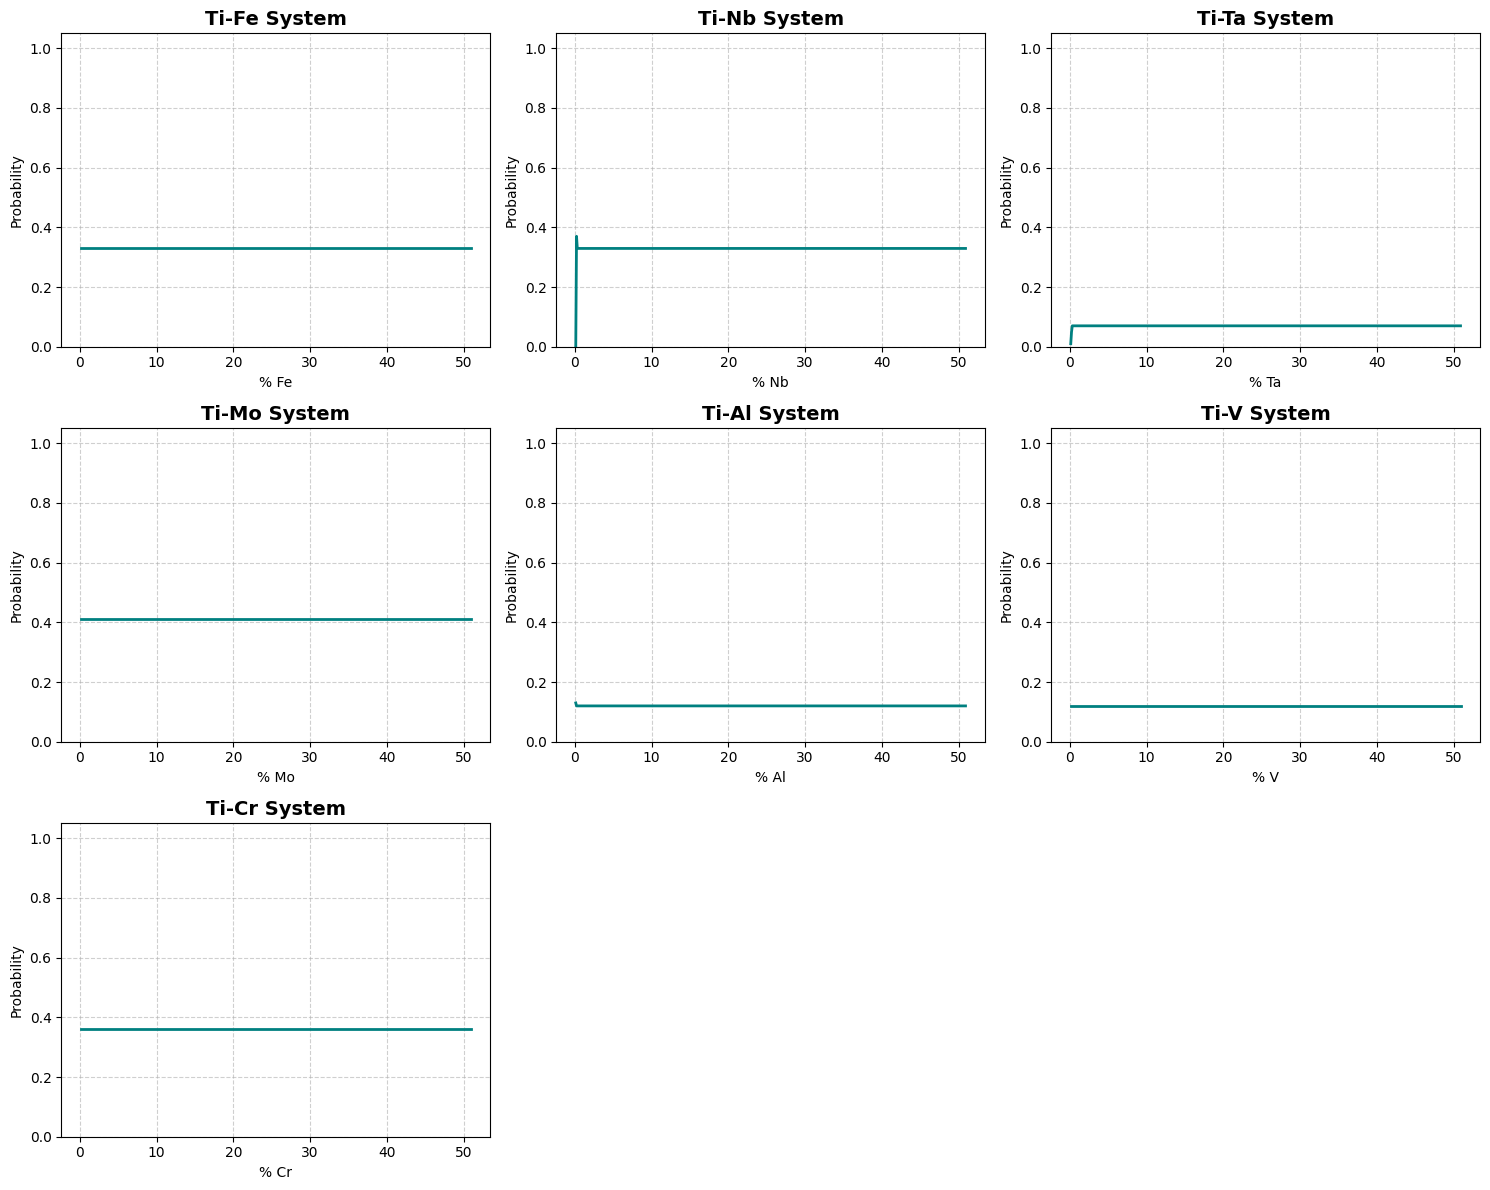

In [120]:
plt_el = ['Fe', 'Nb', 'Ta', 'Mo', 'Al', 'V', 'Cr']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() 

# 2. Iterate and Plot
for i, el in enumerate(plt_el):
    raw_data = synthetic_dict[el]
    scaled_data = scaler.transform(raw_data)
    y_proba = models['rf'].predict_proba(scaled_data)[:, 1]
    
    # Plotting logic
    ax = axes[i]
    ax.plot(percentages, y_proba, color='teal', linewidth=2)
    ax.set_title(f"Ti-{el} System", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"% {el}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.05) # Probabilities stay between 0 and 1
    ax.grid(True, linestyle='--', alpha=0.6)

# 3. Clean up empty subplots
for j in range(len(plt_el), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

This is honestly really hard to interpret, as the probability does not appear to increase as the concentration of the element increases. If you take the base flat probability as the effectiveness of the stabilizer, then Mo, Cr, Fe and Nb are the strongest stabilizers. Then V, Ta, and Al are somewhat poor beta stabilizers.

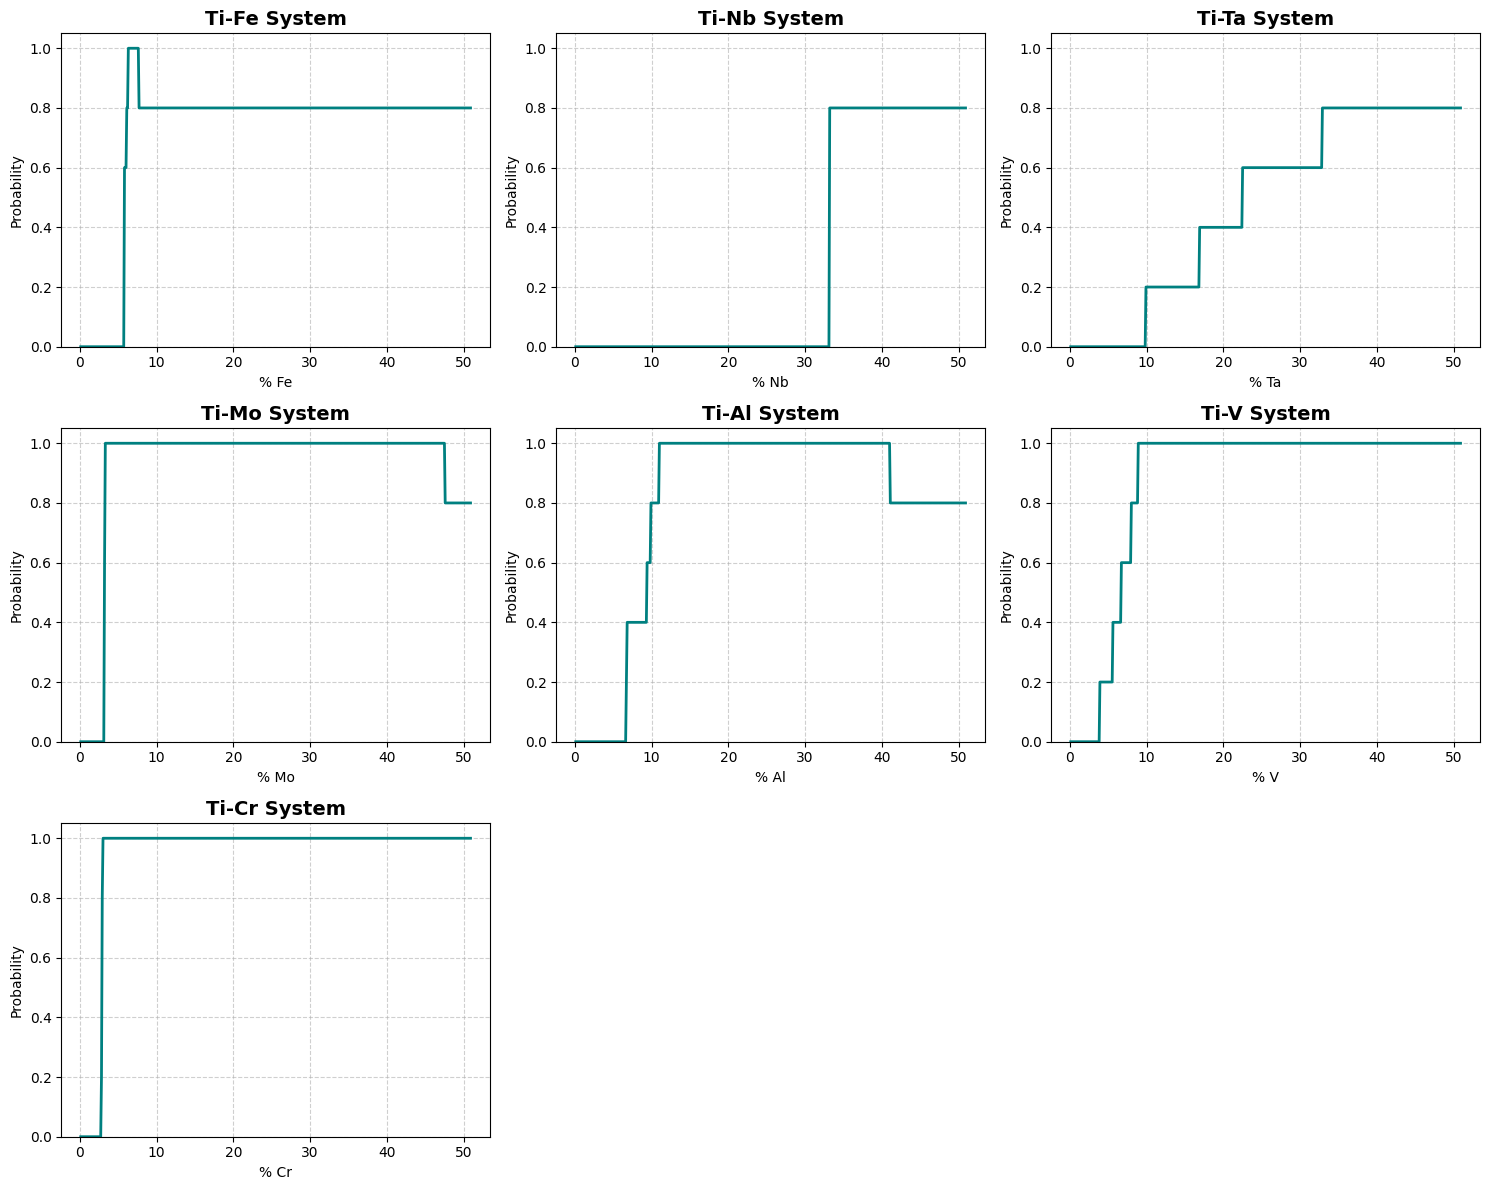

In [121]:
plt_el = ['Fe', 'Nb', 'Ta', 'Mo', 'Al', 'V', 'Cr']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() 

# 2. Iterate and Plot
for i, el in enumerate(plt_el):
    raw_data = synthetic_dict[el]
    scaled_data = scaler.transform(raw_data)
    y_proba = models['knns'].predict_proba(scaled_data)[:, 1]
    
    # Plotting logic
    ax = axes[i]
    ax.plot(percentages, y_proba, color='teal', linewidth=2)
    ax.set_title(f"Ti-{el} System", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"% {el}")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.05) # Probabilities stay between 0 and 1
    ax.grid(True, linestyle='--', alpha=0.6)

# 3. Clean up empty subplots
for j in range(len(plt_el), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The other models also had a similar sharp and unintelligible boundary as rf, except for logistic and knns. 

Chromium and Molybdenum are the best beta stabilizers according to knns. Fe, Al, and V are the next category of elements which are somewhat good beta stabilizers. Finally, Nb and Ta are beta stabilizers, but aren't quite as strong. Specifically Nb has an extremely sharp transition at around 32%, which is likely indication that there should be more data about Nb dopants within Ti alloys.

This dataset has less than 500 entries in it, and so I don't think there is a great predictor here.

### 1.3 Creating a Simpler Baseline

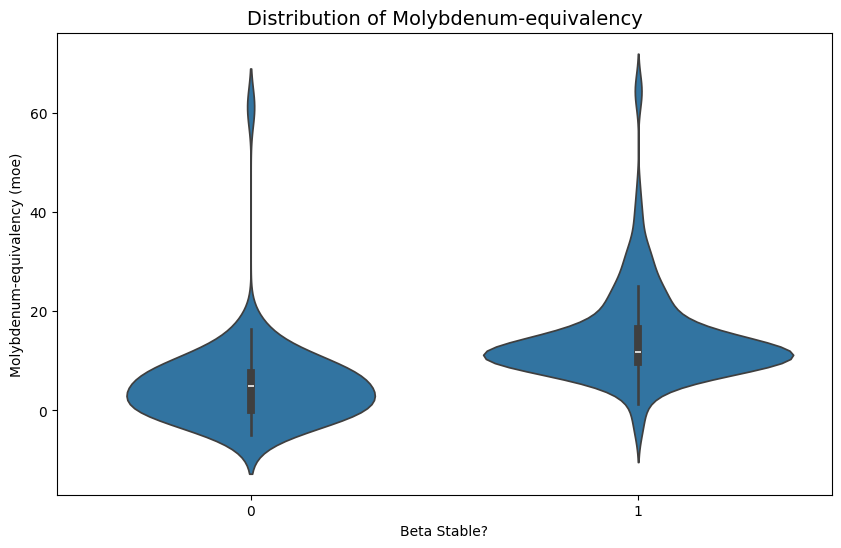

In [122]:
plt.figure(figsize=(10, 6))
sns.violinplot(data = df, y='moe', x='beta')
plt.title('Distribution of Molybdenum-equivalency', fontsize=14)
plt.xlabel('Beta Stable?')
plt.ylabel('Molybdenum-equivalency (moe)')
plt.show()

In [123]:
model_simple = LogisticRegression()
x = df[['moe']]

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.8, random_state= 68)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

# Create the new entry
new_data = {
    'Simple Logistic Model': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': "N/A"
    }
}

new_entry_df = pd.DataFrame(new_data)
results_df = pd.concat([results_df.T, new_entry_df], axis=1)

display(results_df.T)

,accuracy,precision,recall,f1_score,roc_auc
logistic,0.877193,0.865385,1.0,0.927835,0.874074
SVC,0.894737,0.882353,1.0,0.9375,0.859259
tree,0.894737,0.933333,0.933333,0.933333,0.838889
rf,0.912281,0.916667,0.977778,0.946237,0.875926
knns,0.877193,0.913043,0.933333,0.923077,0.875926
xgboost,0.894737,0.914894,0.955556,0.934783,0.927778
Simple Logistic Model,0.859649,0.911111,0.911111,0.911111,N/A


This model is worse than all the other models, which is good news, but the more complex models are only marginally better in f1_score. There is a strong argument that this simple model is therefore better because although it has a lower precision, accuracy, and recall, there is genuine scientific interpretability in the data. 

## 2 Regression

### 2.1 Training and evaluating regressors

In [132]:
target_cols = ["UTS", "DAR"]
df_cleaned = df.dropna(subset=target_cols)
x = compositions.loc[df_cleaned.index].values

y_1 = df_cleaned["UTS"].values
y_2 = df_cleaned["DAR"].values

In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

kernel = 1.0 * RBF(length_scale=1.0)

models = {
    'linreg': LinearRegression(),
    'polyreg': make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), Ridge(alpha=1.0)),
    'Random Forest Reg': RandomForestRegressor(n_estimators=100),
    'GPR': GaussianProcessRegressor(kernel=kernel, alpha = 0.1, random_state=42, normalize_y=True),
    "XGboost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
}

x_1_train, x_1_test, y_1_train, y_1_test = train_test_split(x, y_1, train_size= 0.8, random_state= 68)
x_2_train, x_2_test, y_2_train, y_2_test = train_test_split(x, y_2, train_size= 0.8, random_state= 68)
scaler = StandardScaler()
x1_train_scaled = scaler.fit_transform(x_1_train)
X1_test_scaled = scaler.transform(x_1_test)
x2_train_scaled = scaler.fit_transform(x_2_train)
X2_test_scaled = scaler.transform(x_2_test)

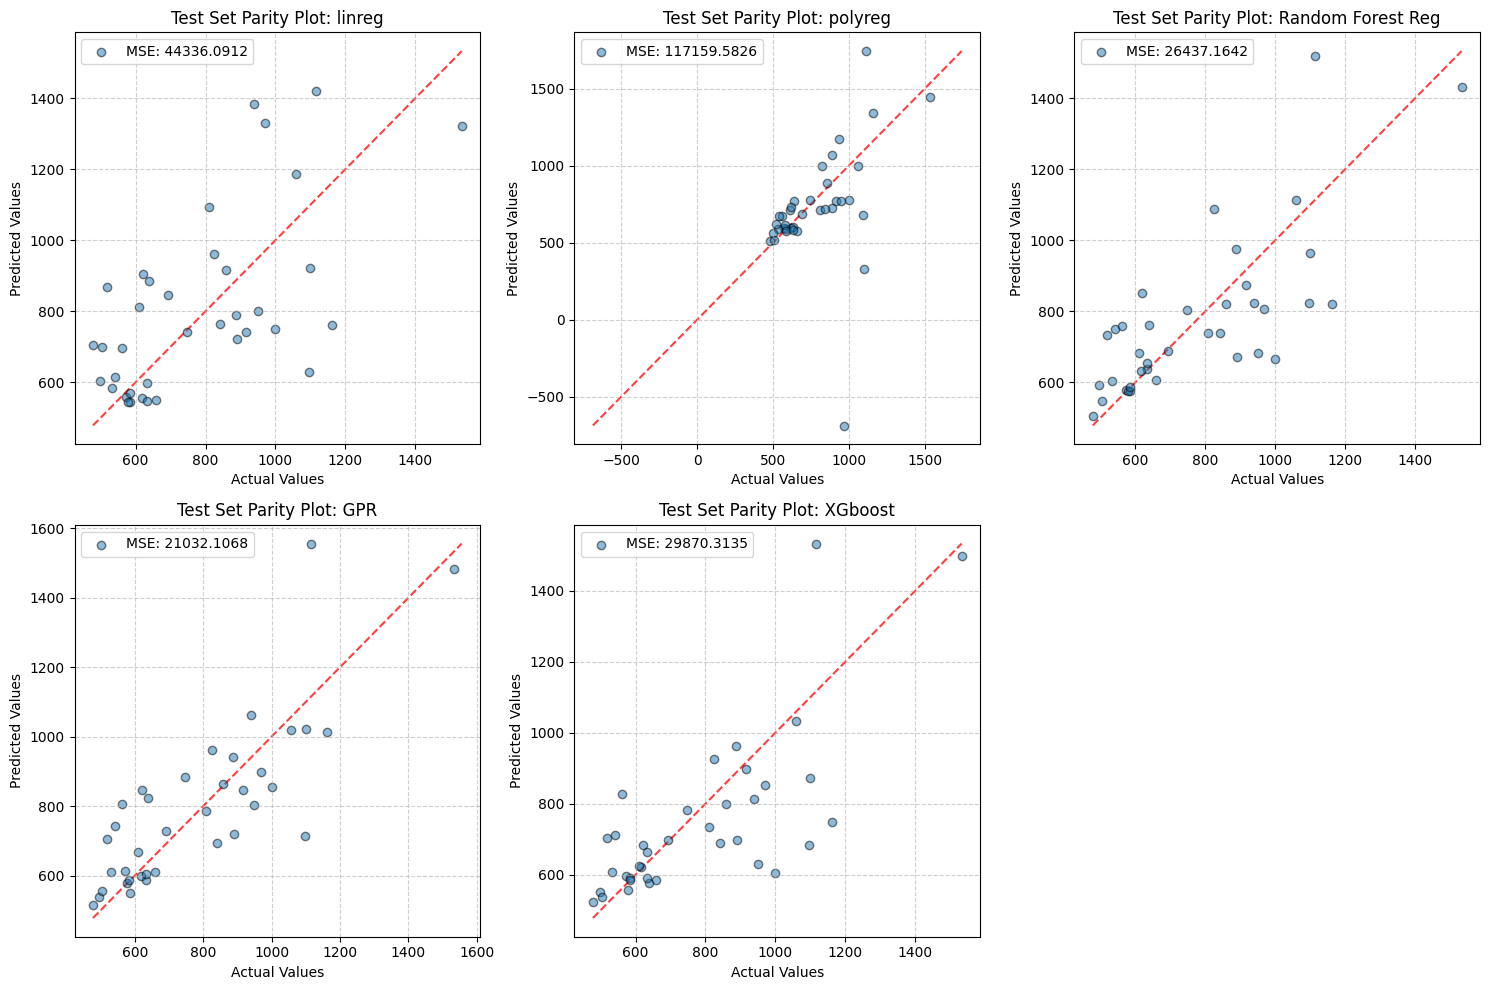

In [158]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 

for i, (name, model) in enumerate(models.items()):
    model.fit(x_1_train, y_1_train)
    preds = model.predict(x_1_test)
    mse = mean_squared_error(y_1_test, preds)
    ax = axes[i]
    ax.scatter(y_1_test, preds, alpha=0.5, edgecolors='k', label=f"MSE: {mse:.4f}")
    lims = [
        np.min([y_1_test.min(), preds.min()]),
        np.max([y_1_test.max(), preds.max()])
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"Test Set Parity Plot: {name}")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

if len(models) < len(axes):
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

For the UTS, GPR is the best performing model with the lowest mean squared error of 21032.

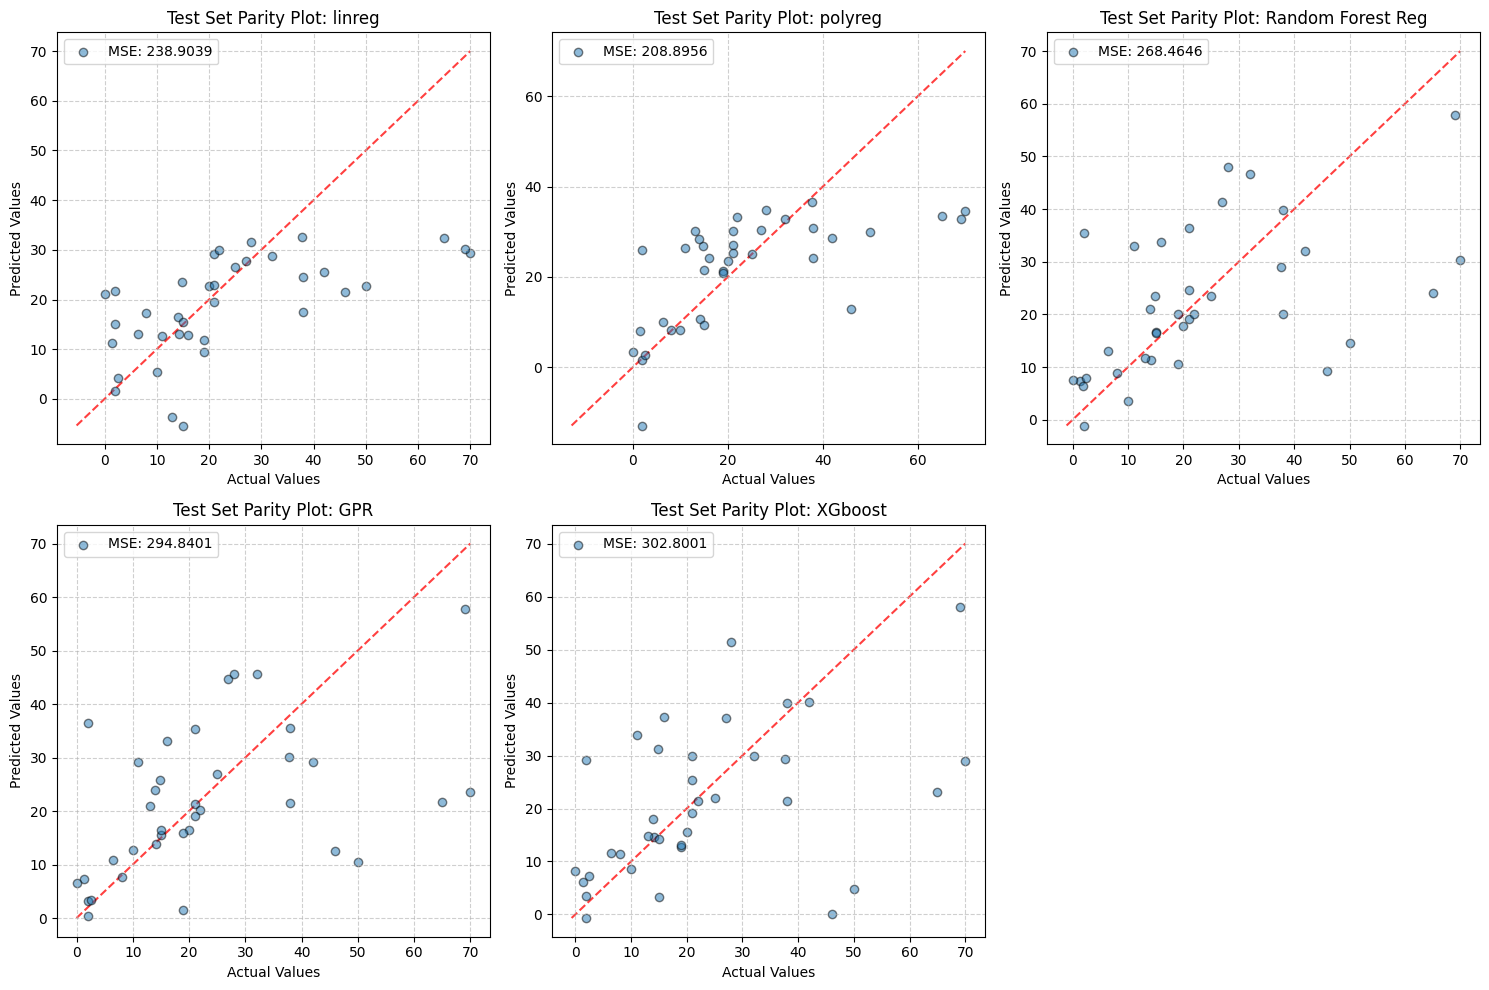

In [157]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 

for i, (name, model) in enumerate(models.items()):
    model.fit(x_2_train, y_2_train)
    preds = model.predict(x_2_test)
    mse = mean_squared_error(y_2_test, preds)
    ax = axes[i]
    ax.scatter(y_2_test, preds, alpha=0.5, edgecolors='k', label=f"MSE: {mse:.4f}")
    lims = [
        np.min([y_2_test.min(), preds.min()]),
        np.max([y_2_test.max(), preds.max()])
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"Test Set Parity Plot: {name}")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

if len(models) < len(axes):
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

For ductility at rupture, polynomial regression was surprisingly the best predictor.

In [153]:
y_combined = np.column_stack((y_1, y_2)) 

X_train, X_test, y_train, y_test = train_test_split(
    x, y_combined, train_size=0.8, random_state=68
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [154]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)
# considering y_train as defined as a two-column matrix (UTS and DAR)
grid_search.fit(X_train, y_train[:, 0])


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [156]:
from scipy.stats import pearsonr

results_list = []
for i, params in enumerate(grid_search.cv_results_['params']):
    # Extract the cross-validated (validation) RMSE (note: scores are negative).
    val_rmse = -grid_search.cv_results_['mean_test_score'][i]

    # Instantiate and train a new RandomForestRegressor with the candidate parameters on the full
    # training set.
    rf_candidate = RandomForestRegressor(**params)
    rf_candidate.fit(X_train, y_train[:, 0])

    y_pred_test = rf_candidate.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test[:, 0], y_pred_test))
    test_corr, _ = pearsonr(y_test[:, 0], y_pred_test)

    # Record all parameters and metrics in a dictionary.
    result_entry = params.copy()
    result_entry.update({
        'validation_rmse': val_rmse,
        'test_rmse': test_rmse,
        'test_corr': test_corr
    })
    results_list.append(result_entry)

# Create a Pandas DataFrame with all the results.
results_df = pd.DataFrame(results_list)

In [166]:
top_corr_indices = results_df['test_corr'].nlargest(3).index

print(f"{'Index':<8} | {'Test Corr':<10} | {'Parameters'}")
print("-" * 60)

for idx in top_corr_indices:
    # Access the specific parameter dict using the dataframe index
    params = grid_search.cv_results_['params'][idx]
    corr_val = results_df.loc[idx, 'test_corr']
    
    print(f"{idx:<8} | {corr_val:<10.4f} | {params}")

bottom_rmse_indices = results_df['test_rmse'].nsmallest(3).index
print(f"\n\n{'Index':<8} | {'Test RMSE':<10} | {'Parameters'}")
print("-" * 60)

for idx in bottom_rmse_indices:
    # Access the specific parameter dict using the dataframe index
    params = grid_search.cv_results_['params'][idx]
    rmse_val = results_df.loc[idx, 'test_rmse']
    
    print(f"{idx:<8} | {rmse_val:<10.4f} | {params}")

Index    | Test Corr  | Parameters
------------------------------------------------------------
5        | 0.7713     | {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
31       | 0.7711     | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
30       | 0.7689     | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


Index    | Test RMSE  | Parameters
------------------------------------------------------------
30       | 153.7715   | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
31       | 153.9757   | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
29       | 156.8823   | {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


The best models appear to have the parameters of max depth 5, min_samples_leaf 1, min_samples_split 5, and n_estimators of 50 and 100, as these are the models with the highest test corr and the lowest test RMSE.